In [19]:
pip install librosa matplotlib SpeechRecognition scikit-learn pydub


Note: you may need to restart the kernel to use updated packages.


# 1. Audio File and Feature Extraction:


In [155]:
import os
import librosa
import numpy as np
import speech_recognition as sr

audio_dir = r"C:\Users\nithi\OneDrive\Documents\Desktop\ASSIGNMNENT\audio_files"
audio_files = [f for f in os.listdir(audio_dir) if f.lower().endswith(".wav")]
filenames = []
raw_features = []
transcripts = []

for fname in audio_files:
    file_path = os.path.join(audio_dir, fname)
    y, sr_loaded = librosa.load(file_path, sr=None)
    
    recognizer = sr.Recognizer()
    with sr.AudioFile(file_path) as source:
        audio_data = recognizer.record(source)
    transcript = recognizer.recognize_google(audio_data)
    transcripts.append(transcript)

    duration = librosa.get_duration(y=y, sr=sr_loaded)
    pitch = librosa.yin(y, fmin=50, fmax=300)
    pitch_variability = np.std(pitch)

    word_count = len(transcript.split())
    speech_rate = word_count / duration if duration else 0
    ums = transcript.lower().count("um") + transcript.lower().count("uh")

    features = [speech_rate, ums, pitch_variability, duration, word_count]
    filenames.append(fname)
    raw_features.append(features)


# 2. Raw Features and Visualization

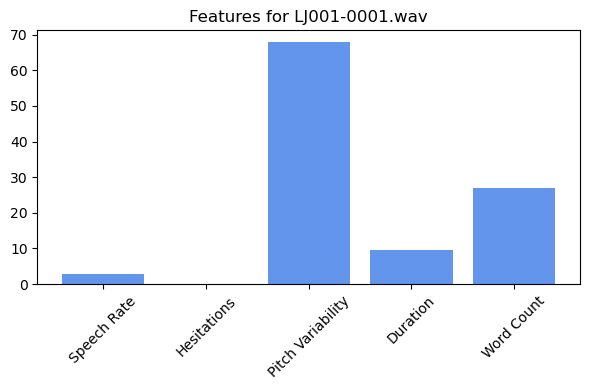

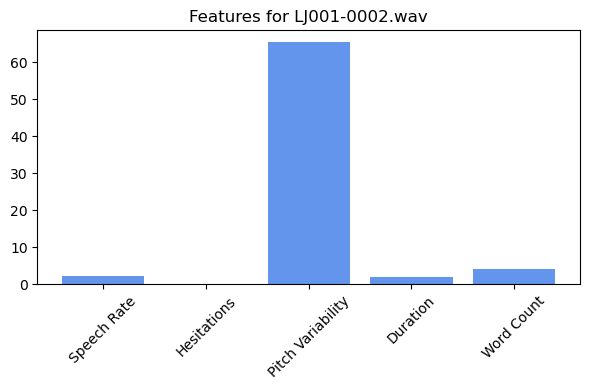

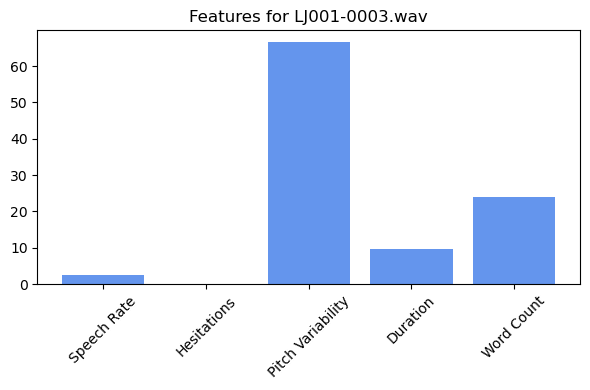

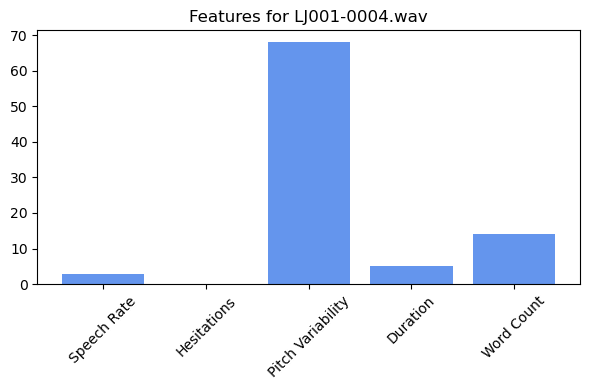

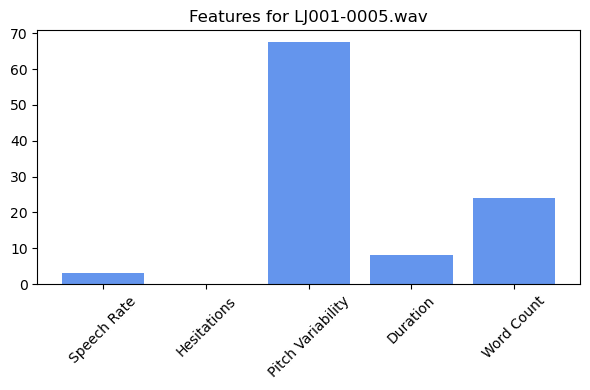

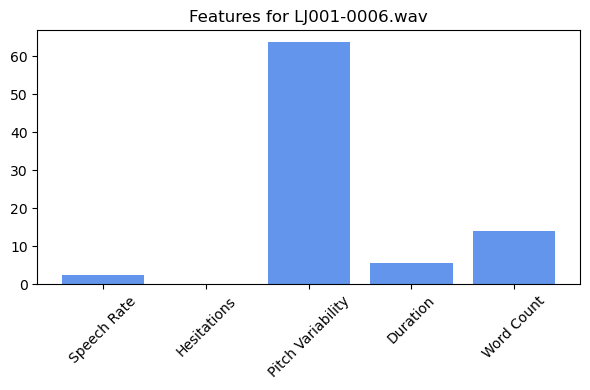

In [157]:
import numpy as np
import matplotlib.pyplot as plt

feature_names = ["Speech Rate", "Hesitations", "Pitch Variability", "Duration", "Word Count"]
features = np.array(raw_features)

for i, feat in enumerate(features):
    plt.figure(figsize=(6, 4))
    plt.bar(feature_names, feat, color='cornflowerblue')
    plt.title(f"Features for {filenames[i]}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


# 3. KMeans Clustering:

C:\Users\nithi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


      Filename  Cluster Label
LJ001-0001.wav              1
LJ001-0002.wav              0
LJ001-0003.wav              1
LJ001-0004.wav              0
LJ001-0005.wav              1
LJ001-0006.wav              0


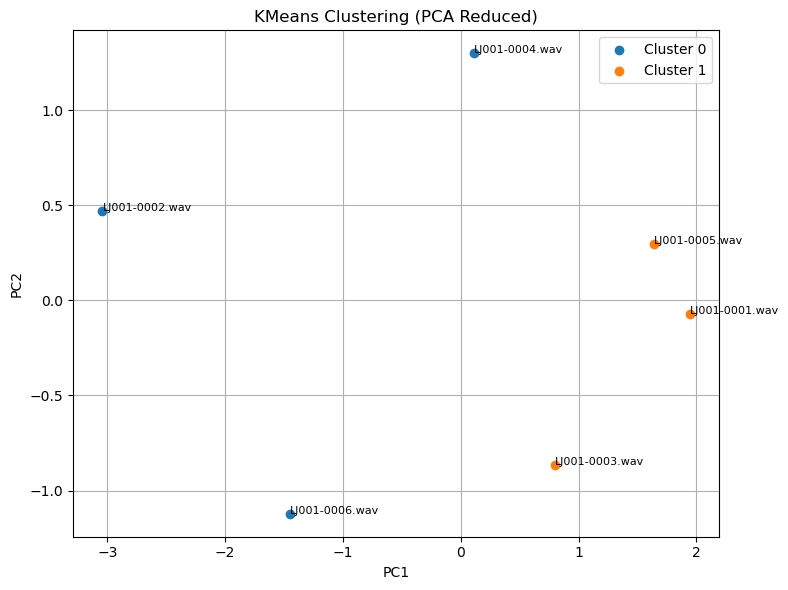

In [163]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Assuming final_features is already available from the feature extraction code
features = np.array(raw_features)

if features.shape[0] < 2:
    print("Need at least 2 valid audio samples for clustering.")
else:
    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(features)

    kmeans = KMeans(n_clusters=2, random_state=0)
    labels = kmeans.fit_predict(features_scaled)

    classification_df = pd.DataFrame({
        "Filename": filenames,
        "Cluster Label": labels
    })
    print(classification_df.to_string(index=False))

    reduced = PCA(n_components=2).fit_transform(features_scaled)

    plt.figure(figsize=(8, 6))
    for label in np.unique(labels):
        idx = labels == label
        plt.scatter(reduced[idx, 0], reduced[idx, 1], label=f"Cluster {label}")

    for i, name in enumerate(filenames):
        plt.annotate(name, (reduced[i, 0], reduced[i, 1]), fontsize=8)

    plt.title("KMeans Clustering (PCA Reduced)")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# 4. Cosine Similarity:


=== Cosine Similarity Matrix ===
LJ001-0001.wav vs LJ001-0002.wav: 0.945
LJ001-0001.wav vs LJ001-0003.wav: 0.999
LJ001-0001.wav vs LJ001-0004.wav: 0.983
LJ001-0001.wav vs LJ001-0005.wav: 0.999
LJ001-0001.wav vs LJ001-0006.wav: 0.986
LJ001-0002.wav vs LJ001-0003.wav: 0.954
LJ001-0002.wav vs LJ001-0004.wav: 0.989
LJ001-0002.wav vs LJ001-0005.wav: 0.958
LJ001-0002.wav vs LJ001-0006.wav: 0.986
LJ001-0003.wav vs LJ001-0004.wav: 0.988
LJ001-0003.wav vs LJ001-0005.wav: 1.000
LJ001-0003.wav vs LJ001-0006.wav: 0.991
LJ001-0004.wav vs LJ001-0005.wav: 0.990
LJ001-0004.wav vs LJ001-0006.wav: 1.000
LJ001-0005.wav vs LJ001-0006.wav: 0.992


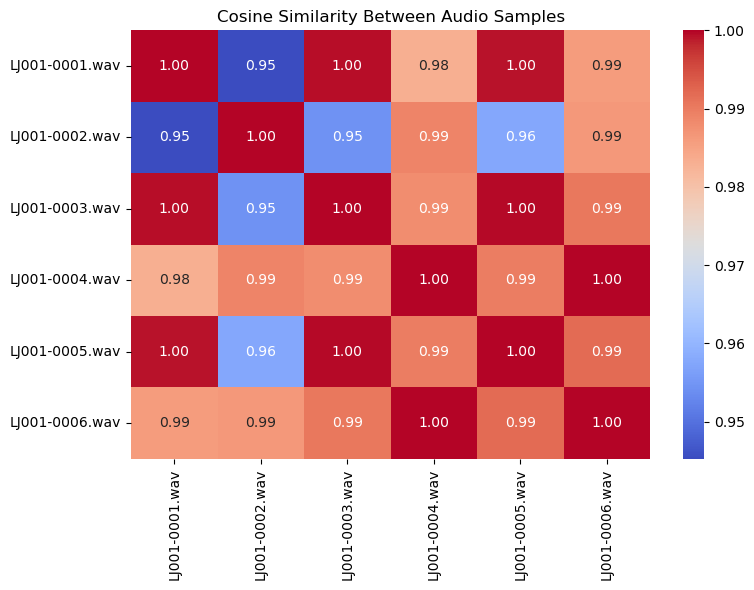

In [165]:
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt

features = np.array(raw_features)

similarity_matrix = cosine_similarity(features)

print("\n=== Cosine Similarity Matrix ===")
for i in range(len(filenames)):
    for j in range(i+1, len(filenames)):
        print(f"{filenames[i]} vs {filenames[j]}: {similarity_matrix[i][j]:.3f}")

plt.figure(figsize=(8, 6))
sns.heatmap(similarity_matrix, xticklabels=filenames, yticklabels=filenames,
            cmap="coolwarm", annot=True, fmt=".2f")
plt.title("Cosine Similarity Between Audio Samples")
plt.tight_layout()
plt.show()


# 5. Anomaly Detection with Isolation Forest:


=== Anomaly Detection (Isolation Forest) ===
LJ001-0001.wav: Normal
LJ001-0002.wav: Anomalous
LJ001-0003.wav: Normal
LJ001-0004.wav: Normal
LJ001-0005.wav: Normal
LJ001-0006.wav: Normal


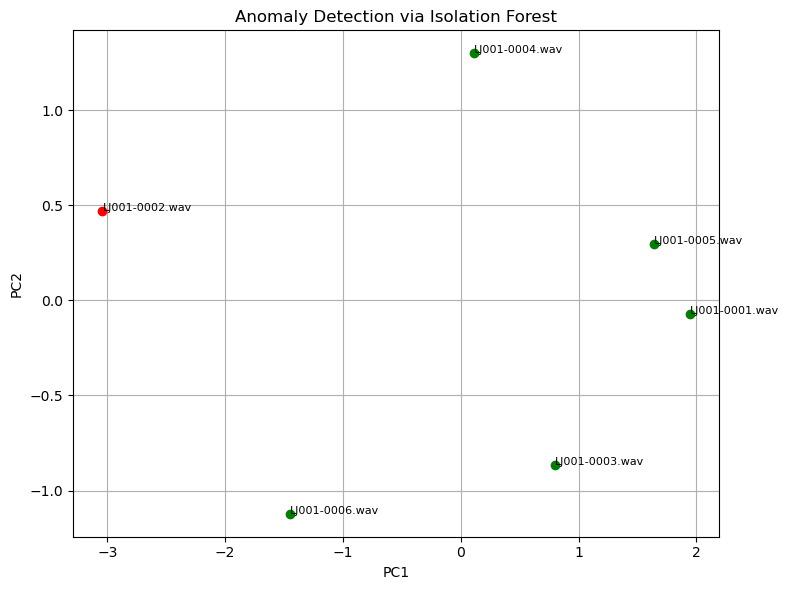

In [167]:
from sklearn.ensemble import IsolationForest

iso_forest = IsolationForest(contamination=0.2, random_state=0)
anomaly_preds = iso_forest.fit_predict(features)

print("\n=== Anomaly Detection (Isolation Forest) ===")
for i, name in enumerate(filenames):
    label = "Anomalous" if anomaly_preds[i] == -1 else "Normal"
    print(f"{name}: {label}")

plt.figure(figsize=(8, 6))
for i, pred in enumerate(anomaly_preds):
    color = "red" if pred == -1 else "green"
    plt.scatter(reduced[i, 0], reduced[i, 1], color=color)
    plt.annotate(filenames[i], (reduced[i, 0], reduced[i, 1]), fontsize=8)

plt.title("Anomaly Detection via Isolation Forest")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.tight_layout()
plt.show()


# t-SNE (t-Distributed Stochastic Neighbor Embedding) for Dimensionality Reduction

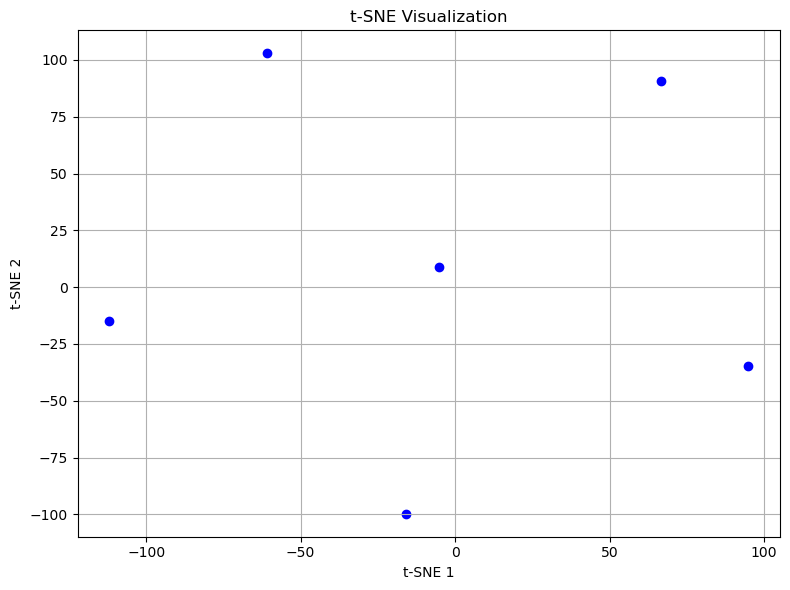

In [177]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

perplexity_value = min(5, len(features_scaled) - 1)  

tsne = TSNE(n_components=2, perplexity=perplexity_value, random_state=0)
tsne_result = tsne.fit_transform(features_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(tsne_result[:, 0], tsne_result[:, 1], c='blue')
plt.title("t-SNE Visualization")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.grid(True)
plt.tight_layout()
plt.show()


# One-Class SVM (Support Vector Machine) for Anomaly Detection

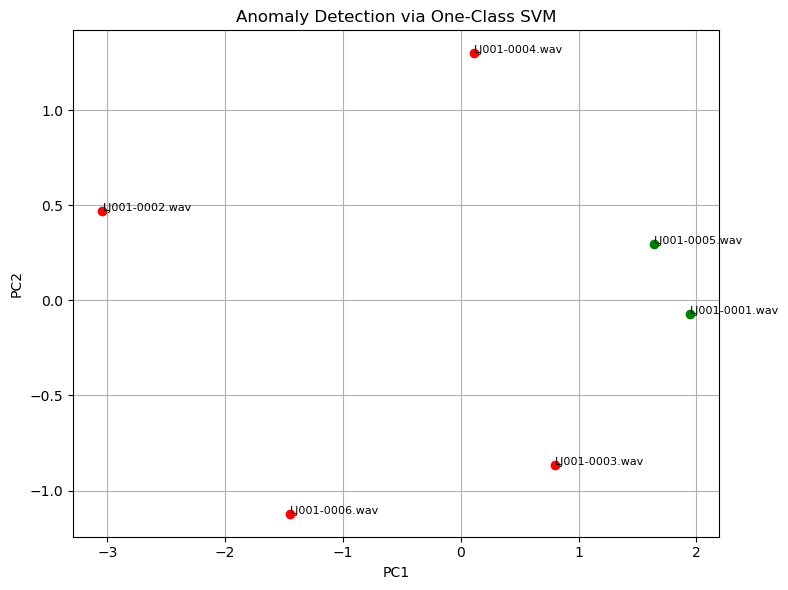

In [174]:
from sklearn.svm import OneClassSVM
import matplotlib.pyplot as plt

ocsvm = OneClassSVM(nu=0.2, kernel="rbf", gamma="scale")
ocsvm_preds = ocsvm.fit_predict(features_scaled)

plt.figure(figsize=(8, 6))
for i, pred in enumerate(ocsvm_preds):
    color = "red" if pred == -1 else "green"
    plt.scatter(reduced[i, 0], reduced[i, 1], color=color)
    plt.annotate(filenames[i], (reduced[i, 0], reduced[i, 1]), fontsize=8)

plt.title("Anomaly Detection via One-Class SVM")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.tight_layout()
plt.show()
